# Estandarización de títulos y clasificación de tickets

Este notebook implementa el tercer experimento del proyecto MIA para evaluar el impacto de la estandarización de títulos en la clasificación inicial de tickets de una mesa de ayuda TI universitaria.

El flujo desarrollado parte del pipeline baseline previamente implementado y añade un módulo de estandarización de títulos basado en reglas heurísticas, diccionarios de servicios y expresiones regulares.

El objetivo es evaluar el desempeño del clasificador utilizando títulos estandarizados y determinar el impacto de esta transformación sobre la clasificación de los tickets.

Flujo general:

Cargar datos → EDA básico → Preparar datos → Analizar servicios y títulos frecuentes → Construir reglas de estandarización → Generar títulos estandarizados → Limpiar texto → Vectorizar con TF-IDF → Entrenar Logistic Regression → Evaluar con Classification Report y matriz de confusión

## 1. Configuración inicial

En esta sección se cargan las librerías necesarias, se define la semilla aleatoria y se configuran las rutas de trabajo en Google Drive.

In [1]:
# Librerías estándar
import os
import re
import string
import warnings

# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Configuración general
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Configuración inicial completada.")

✅ Configuración inicial completada.


## 2. Carga del dataset

En esta sección se conecta Google Drive y se carga el archivo original de tickets ubicado en la carpeta `01_data/raw`.

In [2]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Ruta principal del proyecto
PROJECT_ROOT = "/content/drive/MyDrive/Proyecto_MIA"

# Ruta del dataset original
DATASET_PATH = f"{PROJECT_ROOT}/01_data/raw/tickets_raw_corte_01_2026-02-25.xlsx"

# Cargar dataset
df = pd.read_excel(DATASET_PATH)

print(f"Dataset cargado correctamente.")
print(f"Registros: {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")

Mounted at /content/drive
Dataset cargado correctamente.
Registros: 24,392
Columnas : 42


## 3. EDA básico

En esta sección se realiza una revisión inicial del dataset para validar su estructura, identificar valores nulos y revisar la distribución de la variable objetivo `Grupo`.

In [3]:
# Dimensiones del dataset

print(f"Número de registros : {df.shape[0]:,}")
print(f"Número de columnas  : {df.shape[1]}")

display(df.head())

Número de registros : 24,392
Número de columnas  : 42


,Fecha de registro,Código,Título,Estado,Fecha firma cierre,Acción a realizar,Fecha firma solución,Firma solución,Escalado,Tipo,...,SLA,Solución para el usuario,Técnico que realiza última comunicación a cliente,Tiempo 1ª respuesta,Tiempo atención (horas / minutos),Tiempo de atención,Tiempo de cierre,Tiempo de cierre (horas / minutos),Tiempo de resolución,Última comunicación a cliente
0,2023-02-08 17:33:06,REQ 2023-003487,RV: Entrega de novedades SEGUNDO SEMESTRE 2022...,Cerrada,2025-09-11 09:32:55,Escalar a 2ª línea,2025-09-01 09:31:12,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5815.517578,0h 00m,0.00,5887.534241,5887h 32m,5815.517578,NaT
1,2023-02-09 10:00:07,REQ 2023-003539,RE: Entrega de novedades SEGUNDO SEMESTRE 2022...,Cerrada,2025-09-11 09:32:55,Escalar a 2ª línea,2025-09-01 09:31:12,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5813.517187,1h 24m,1.40,5885.533850,5885h 32m,5813.517187,NaT
2,2023-02-14 12:57:06,REQ 2023-003967,FORMULARIO 107,Cerrada,2025-09-11 09:32:55,Escalar a 2ª línea,2025-09-01 09:31:11,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5783.567188,5h 27m,5.45,5855.583851,5855h 35m,5783.567188,NaT
3,2023-02-20 17:45:06,REQ 2023-004390,Formulario 107,Cerrada,2025-09-11 09:32:54,Escalar a 2ª línea,2025-09-01 09:31:11,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5743.500000,3h 00m,3.00,5815.516663,5815h 31m,5743.500000,NaT
4,2023-02-22 11:18:06,REQ 2023-004477,Problemas en el servidor,Cerrada,2025-09-11 09:32:54,Escalar a 2ª línea,2025-09-01 09:31:10,"Tufiño Benalcázar, Carlos",Sí,Solicitud RRHH,...,SLA 24 Hrs RRHH,Solucionado,NaN,5731.217318,0h 08m,0.13,5803.233980,5803h 14m,5731.217318,NaT


In [4]:
# Información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24392 entries, 0 to 24391
Data columns (total 42 columns):
 #   Column                                             Non-Null Count  Dtype         
---  ------                                             --------------  -----         
 0   Fecha de registro                                  24392 non-null  datetime64[ns]
 1   Código                                             24392 non-null  object        
 2   Título                                             24392 non-null  object        
 3   Estado                                             24392 non-null  object        
 4   Fecha firma cierre                                 14364 non-null  datetime64[ns]
 5   Acción a realizar                                  24392 non-null  object        
 6   Fecha firma solución                               16849 non-null  datetime64[ns]
 7   Firma solución                                     16849 non-null  object        
 8   Escalado        

### Análisis preliminar del conjunto de datos

La inspección inicial muestra que el dataset está compuesto por **24.392 tickets** y **42 variables** de diferentes tipos (texto, fechas y variables numéricas).

De acuerdo con el objetivo del proyecto y con las validaciones realizadas con el personal de la mesa de ayuda, el modelo baseline utilizará como variable objetivo el campo **Grupo**, ya que representa la asignación inicial del grupo resolutorio en la mayoría de los casos.

Asimismo, para evitar *Data Leakage*, en esta primera versión no se utilizarán variables que contienen información generada después de la clasificación inicial del ticket, como tiempos de resolución, tiempos de cierre, solución aplicada o información completada posteriormente durante el proceso de atención.

In [5]:
# Distribución de tickets por estado

estado_counts = (
    df["Estado"]
    .value_counts(dropna=False)
    .reset_index()
)

estado_counts.columns = ["Estado", "Cantidad"]

display(estado_counts)

print(f"\nNúmero de estados encontrados: {df['Estado'].nunique()}")

,Estado,Cantidad
0,Cerrada,18855
1,Rechazada,4687
2,Resuelta,445
3,Asignada a un grupo,388
4,Nueva,17



Número de estados encontrados: 5


### Selección de los tickets para el entrenamiento

El análisis de la variable **Estado** muestra que la mayoría de los tickets corresponden a los estados **Cerrada** y **Rechazada**.

De acuerdo con la validación realizada con el personal de la Dirección de Tecnologías, estos estados representan casos con una resolución definitiva. En cambio, los tickets en estado **Resuelta** pueden volver a abrirse si el usuario no está conforme con la solución, mientras que los estados **Nueva** y **Asignada a un grupo** corresponden a casos que aún se encuentran en proceso.

Por este motivo, el modelo baseline será entrenado únicamente con tickets en estado **Cerrada** y **Rechazada**, garantizando que el conjunto de entrenamiento represente decisiones operativas consolidadas y evitando incorporar registros cuyo flujo aún no ha finalizado.

In [6]:
# Valores nulos en las variables relevantes del proyecto

columnas_interes = ["Título", "Descripción", "Grupo"]

nulos = (
    df[columnas_interes]
    .isnull()
    .sum()
    .reset_index()
)

nulos.columns = ["Variable", "Valores nulos"]
nulos["Porcentaje (%)"] = (
    nulos["Valores nulos"] / len(df) * 100
).round(2)

display(nulos)

,Variable,Valores nulos,Porcentaje (%)
0,Título,0,0.00
1,Descripción,316,1.30
2,Grupo,7155,29.33


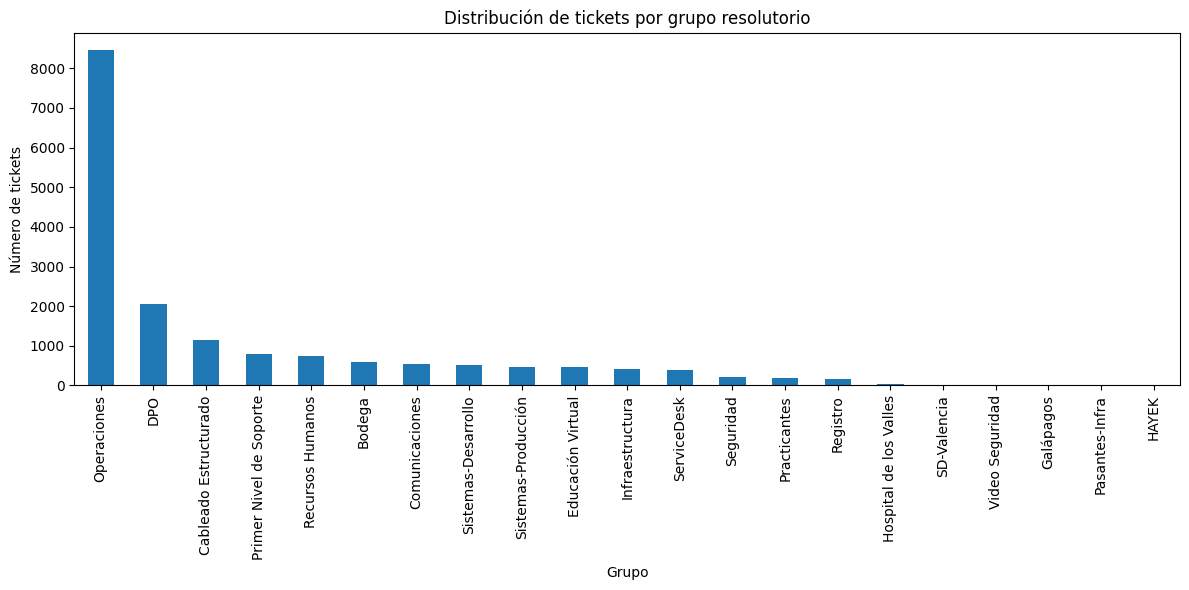

Número de grupos resolutorios: 21


In [7]:
# Distribución de la variable objetivo (Grupo)

grupo_counts = (
    df["Grupo"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
grupo_counts.plot(kind="bar")

plt.title("Distribución de tickets por grupo resolutorio")
plt.xlabel("Grupo")
plt.ylabel("Número de tickets")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

print(f"Número de grupos resolutorios: {grupo_counts.shape[0]}")

### Conclusiones del análisis exploratorio

El análisis exploratorio permitió identificar que el problema corresponde a una tarea de clasificación multiclase con **21 grupos resolutorios**. Asimismo, se verificó la existencia de valores nulos en la variable objetivo (*Grupo*), los cuales deberán tratarse durante la preparación de los datos.

Con base en este análisis, la siguiente etapa consistirá en construir el conjunto de datos que será utilizado para entrenar el modelo baseline.

## 4. Preparación de los datos

En esta sección se construirá el conjunto de datos que será utilizado para entrenar el modelo baseline. Para ello se aplicarán los filtros y transformaciones definidos durante el análisis exploratorio, garantizando que el modelo utilice únicamente información disponible al momento de la clasificación inicial del ticket.

In [8]:
# Construcción del dataset para Machine Learning

df_ml = df[
    (df["Estado"].isin(["Cerrada", "Rechazada"])) &
    (df["Grupo"].notna())
].copy()

print(f"Registros del dataset original : {len(df):,}")
print(f"Registros para Machine Learning: {len(df_ml):,}")
print(f"Registros descartados          : {len(df) - len(df_ml):,}")

Registros del dataset original : 24,392
Registros para Machine Learning: 16,404
Registros descartados          : 7,988


In [9]:
# Verificar valores nulos en las variables utilizadas por el modelo

print("Valores nulos en el dataset de Machine Learning:\n")

print(f"Título      : {df_ml['Título'].isnull().sum()}")
print(f"Descripción : {df_ml['Descripción'].isnull().sum()}")
print(f"Grupo       : {df_ml['Grupo'].isnull().sum()}")

Valores nulos en el dataset de Machine Learning:

Título      : 0
Descripción : 288
Grupo       : 0


In [10]:
# Eliminar registros sin descripción

df_ml = df_ml.dropna(subset=["Descripción"]).copy()

print(f"Registros disponibles para entrenamiento: {len(df_ml):,}")

Registros disponibles para entrenamiento: 16,116


## 5. Análisis para la estandarización de títulos

Antes de construir el texto de entrada del clasificador, se analizarán los campos estructurados `Tipo`, `Categoría` y `SLA`, así como los títulos más frecuentes del conjunto de datos.

Este análisis permitirá identificar servicios, categorías y patrones recurrentes que puedan utilizarse para construir reglas heurísticas de estandarización de títulos. El objetivo es generar títulos más informativos a partir de información disponible en el ticket, manteniendo un enfoque reproducible y basado en los datos históricos de la mesa de ayuda.

### Análisis de los campos estructurados de servicios

Los campos `Tipo`, `Categoría` y `SLA` contienen información estructurada relacionada con la naturaleza y los servicios asociados a los tickets. A continuación, se revisará la cantidad de valores únicos y su distribución para determinar qué información puede ser utilizada en la construcción del módulo de estandarización de títulos.

In [11]:
# Revisar valores únicos y distribución de los campos estructurados
campos_servicio = ["Tipo", "Categoría", "SLA"]

for campo in campos_servicio:
    print(f"\n{'=' * 70}")
    print(f"CAMPO: {campo}")
    print(f"{'=' * 70}")

    print(f"Valores únicos: {df_ml[campo].nunique(dropna=True)}")
    print(f"Valores nulos : {df_ml[campo].isnull().sum()}")

    display(
        df_ml[campo]
        .value_counts(dropna=False)
        .reset_index(name="Cantidad")
        .rename(columns={campo: "Valor"})
    )


CAMPO: Tipo
Valores únicos: 7
Valores nulos : 0


,Valor,Cantidad
0,Petición de Servicio,11750
1,Mantenimiento,2339
2,Error o Fallo,1566
3,Accesos y permisos,288
4,Monitoreo,98
5,Solicitud RRHH,66
6,Solicitud programada,9



CAMPO: Categoría
Valores únicos: 127
Valores nulos : 1872


,Valor,Cantidad
0,/Laptops y PCs,2251
1,"/Proyectores, TVs y monitores interactivos",2123
2,NaN,1872
3,/Laboratorios,1832
4,/Banner,564
...,...,...
123,/Minitab,1
124,/Bot secciones en Banner,1
125,/Asignación de horarios 1er Semestre,1
126,/Redcap,1



CAMPO: SLA
Valores únicos: 8
Valores nulos : 1874


,Valor,Cantidad
0,4 - SLA01 Bronce (24h laborables),10446
1,3 - SLA02 Plata (16h laborables),2001
2,NaN,1874
3,2 - SLA03 Oro (Rápida 8h laborables),1502
4,1 - SLA04 Diamante (Inmediata 4h),179
5,SLA 24 Hrs RRHH,59
6,DPO_SLA 8x5 - 7 días,48
7,SLA 16 Hrs RRHH,5
8,DPO_SLA 24/7 - 15 días,2


### Análisis de las categorías más frecuentes

Dado que el campo `Categoría` contiene un número elevado de valores diferentes, se analizarán las categorías con mayor frecuencia en el conjunto de datos.

Este análisis permitirá identificar los servicios y sistemas más representativos de la mesa de ayuda y evaluar posteriormente su utilidad para la construcción de reglas de estandarización de títulos.

In [12]:
# Mostrar las 30 categorías más frecuentes
categorias_frecuentes = (
    df_ml["Categoría"]
    .dropna()
    .value_counts()
    .head(30)
    .reset_index()
)

categorias_frecuentes.columns = ["Categoría", "Cantidad"]

display(categorias_frecuentes)

,Categoría,Cantidad
0,/Laptops y PCs,2251
1,"/Proyectores, TVs y monitores interactivos",2123
2,/Laboratorios,1832
3,/Banner,564
4,/Trabajo Social,538
5,/Correo Electrónico,524
6,/HUBI,496
7,/D2L,429
8,/Impresoras y scanners,413
9,/Puntos de red,355


### Análisis de los títulos más frecuentes

A continuación, se analizarán los títulos con mayor frecuencia en el conjunto de datos utilizado para Machine Learning.

Este análisis permitirá identificar títulos recurrentes y potencialmente genéricos que no describen de forma suficiente el incidente o requerimiento reportado. Estos títulos serán posteriormente revisados para determinar cuáles requieren reglas específicas de estandarización.

In [13]:
# Mostrar los 30 títulos más frecuentes
titulos_frecuentes = (
    df_ml["Título"]
    .str.strip()
    .value_counts()
    .head(30)
    .reset_index()
)

titulos_frecuentes.columns = ["Título", "Cantidad"]

display(titulos_frecuentes)

,Título,Cantidad
0,NO RESPONDER [Service Desk] Incidencia REQ 202...,278
1,Soporte Salas de Cine,250
2,Administración Service desk,233
3,D2L,155
4,Revisar sistemas de Monitoreo,96
5,Soportes,85
6,Soportes ventanilla,77
7,[Service Desk] Incidencia REQ 2025-018499: RE:...,60
8,Lab BIBHDLV,55
9,Mantenimiento Lab MS209,53


### Normalización exploratoria de títulos

El análisis de los títulos más frecuentes muestra que existen variaciones en su escritura que pueden fragmentar títulos conceptualmente similares, por ejemplo, debido al uso de mayúsculas y minúsculas, prefijos de respuesta o reenvío y espacios adicionales.

Para obtener una visión más consistente de los patrones recurrentes, se generará una versión normalizada de los títulos exclusivamente con fines de análisis. Esta transformación no reemplaza todavía el título original ni constituye la estandarización que posteriormente será evaluada en el clasificador.

A partir de los títulos normalizados se volverá a analizar su frecuencia para identificar candidatos recurrentes que puedan requerir reglas específicas de estandarización.

In [14]:
# Función de normalización exploratoria de títulos
def normalizar_titulo_exploratorio(titulo):
    titulo = str(titulo).strip().lower()

    # Eliminar prefijos habituales de respuestas y reenvíos
    titulo = re.sub(r"^(re|rv|fw|fwd)\s*:\s*", "", titulo)

    # Reemplazar múltiples espacios por uno solo
    titulo = re.sub(r"\s+", " ", titulo).strip()

    return titulo


# Crear una versión normalizada únicamente para el análisis exploratorio
df_ml["Titulo_Exploratorio"] = (
    df_ml["Título"].apply(normalizar_titulo_exploratorio)
)

# Mostrar los 30 títulos normalizados más frecuentes
titulos_normalizados_frecuentes = (
    df_ml["Titulo_Exploratorio"]
    .value_counts()
    .head(30)
    .reset_index()
)

titulos_normalizados_frecuentes.columns = [
    "Título normalizado",
    "Cantidad"
]

display(titulos_normalizados_frecuentes)

,Título normalizado,Cantidad
0,no responder [service desk] incidencia req 202...,278
1,soporte salas de cine,250
2,administración service desk,233
3,d2l,158
4,revisar sistemas de monitoreo,96
5,soportes,85
6,soportes ventanilla,77
7,[service desk] incidencia req 2025-018499: re:...,60
8,lab bibhdlv,55
9,mantenimiento lab ms209,53


### Identificación de títulos recurrentes candidatos a estandarización

Los títulos más frecuentes del conjunto de datos están dominados por actividades operativas recurrentes, especialmente relacionadas con soporte y mantenimiento de laboratorios. Por este motivo, limitar el análisis únicamente a los 30 títulos con mayor frecuencia podría excluir otros títulos genéricos relevantes.

A continuación, se ampliará el análisis de títulos recurrentes para disponer de un conjunto mayor de candidatos. La frecuencia se utilizará únicamente como criterio de exploración y no como evidencia suficiente para considerar que un título es genérico.

La selección posterior de los títulos que requieren estandarización se realizará considerando su nivel de informatividad y el contenido disponible en los tickets asociados.

In [15]:
# Ampliar el análisis a los 100 títulos normalizados más frecuentes
titulos_recurrentes = (
    df_ml["Titulo_Exploratorio"]
    .value_counts()
    .head(100)
    .reset_index()
)

titulos_recurrentes.columns = [
    "Título normalizado",
    "Cantidad"
]

display(titulos_recurrentes)

,Título normalizado,Cantidad
0,no responder [service desk] incidencia req 202...,278
1,soporte salas de cine,250
2,administración service desk,233
3,d2l,158
4,revisar sistemas de monitoreo,96
...,...,...
95,solicitud de teclado,6
96,creación de cuenta,6
97,no responder [service desk] incidencia req 202...,6
98,no responder [service desk] incidencia req 202...,6


El df generado fue descargado para ser analizado con el siguiente código:

from google.colab import files

nombre_archivo = "titulos_recurrentes_top100.csv"

titulos_recurrentes.to_csv(
    nombre_archivo,
    index=False,
    encoding="utf-8-sig"
)

files.download(nombre_archivo)

### Selección de títulos genéricos para análisis (30)

El análisis ampliado de los títulos recurrentes mostró que una parte importante corresponde a actividades operativas específicas y suficientemente descriptivas, por lo que no resulta apropiado estandarizarlos únicamente por su frecuencia.

En cambio, se identificaron títulos recurrentes que describen únicamente un sistema, servicio o expresión genérica, sin indicar claramente el incidente o requerimiento reportado. Estos títulos serán analizados junto con sus descripciones para determinar si es posible generar una versión más informativa mediante reglas heurísticas.

De forma separada, también se identificaron títulos con estructuras repetitivas generadas por sistemas o cadenas de correo. Estos casos serán tratados posteriormente mediante reglas de limpieza basadas en expresiones regulares.

In [16]:
# Identificar títulos potencialmente genéricos dentro de los 100 más frecuentes

# Términos que representan expresiones genéricas
terminos_genericos = {
    "soporte",
    "soportes",
    "ayuda",
    "urgente",
    "solicitud",
    "no title"
}

# Sistemas o servicios que, usados solos como título,
# no describen el incidente o requerimiento específico
sistemas_genericos = {
    "d2l",
    "banner",
    "wifi",
    "hubi",
    "workflow"
}

def es_candidato_estandarizacion(titulo):
    titulo = str(titulo).strip().lower()

    # Caso 1: expresión genérica
    if titulo in terminos_genericos:
        return True

    # Caso 2: únicamente nombre de sistema o servicio
    if titulo in sistemas_genericos:
        return True

    # Caso 3: título automático con estructura de Service Desk
    if re.search(r"\[service desk\].*(incidencia|req)", titulo):
        return True

    return False


# Aplicar los criterios sobre los 100 títulos recurrentes
titulos_candidatos_revision = (
    titulos_recurrentes[
        titulos_recurrentes["Título normalizado"]
        .apply(es_candidato_estandarizacion)
    ]
    .sort_values("Cantidad", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

titulos_candidatos_revision.columns = [
    "Título candidato",
    "Cantidad"
]

print(
    f"Títulos candidatos identificados: "
    f"{len(titulos_candidatos_revision)}"
)

display(titulos_candidatos_revision)

Títulos candidatos identificados: 16


,Título candidato,Cantidad
0,no responder [service desk] incidencia req 202...,278
1,d2l,158
2,soportes,85
3,[service desk] incidencia req 2025-018499: re:...,60
4,banner,31
5,[service desk] incidencia req 2025-018663: [se...,23
6,[service desk] incidencia req 2025-018657: [se...,23
7,wifi,22
8,no title,15
9,solicitud,9


### Revisión de los títulos candidatos y sus descripciones

Los títulos identificados en la etapa anterior constituyen candidatos potenciales para la estandarización, pero su clasificación como títulos poco informativos debe validarse revisando el contenido de los tickets asociados.

A continuación, se analizarán ejemplos de cada candidato junto con su descripción y categoría. Esta revisión permitirá confirmar qué títulos requieren estandarización, identificar patrones recurrentes en las descripciones y determinar qué tipo de regla puede aplicarse en cada caso.

In [17]:
# Obtener ejemplos de tickets asociados a los títulos candidatos
lista_titulos_candidatos = (
    titulos_candidatos_revision["Título candidato"].tolist()
)

ejemplos_candidatos = (
    df_ml[
        df_ml["Titulo_Exploratorio"].isin(lista_titulos_candidatos)
    ][
        ["Titulo_Exploratorio", "Título", "Descripción", "Categoría"]
    ]
    .groupby("Titulo_Exploratorio", group_keys=False)
    .head(5)
    .sort_values("Titulo_Exploratorio")
)

display(ejemplos_candidatos)

,Titulo_Exploratorio,Título,Descripción,Categoría
15697,[service desk] incidencia req 2025-018499: re:...,[Service Desk] Incidencia REQ 2025-018499: RE:...,\n[https://www.usfq.edu.ec/sites/default/files...,NaN
15696,[service desk] incidencia req 2025-018499: re:...,[Service Desk] Incidencia REQ 2025-018499: RE:...,\n[https://www.usfq.edu.ec/sites/default/files...,NaN
15698,[service desk] incidencia req 2025-018499: re:...,[Service Desk] Incidencia REQ 2025-018499: RE:...,\n[https://www.usfq.edu.ec/sites/default/files...,NaN
15699,[service desk] incidencia req 2025-018499: re:...,[Service Desk] Incidencia REQ 2025-018499: RE:...,\n[https://www.usfq.edu.ec/sites/default/files...,NaN
15694,[service desk] incidencia req 2025-018499: re:...,[Service Desk] Incidencia REQ 2025-018499: RE:...,No se puede modificar la incidencia / petición...,NaN
...,...,...,...,...
4844,workflow,Workflow,no reconoce la cuenta de la universidad luego ...,/Workflow
5368,workflow,Workflow,"Hola equipo, \n\nHe intentado acceder a mi D2L...",/Banner
6598,workflow,Workflow,"Buenos días. \n\nNo soy administrativa, soy es...",/Workflow
246,workflow,Workflow,"Estimados,\n\nEstoy intentando ingresar a work...",/Workflow


### Estrategias identificadas para la estandarización

La revisión de los títulos candidatos junto con sus descripciones permitió identificar que no todos los casos requieren el mismo tratamiento.

Se identificaron tres estrategias principales:

- **Limpieza mediante expresiones regulares:** para títulos generados automáticamente por el sistema Service Desk que contienen estructuras repetitivas o información técnica que puede eliminarse para recuperar el contenido relevante del título.

- **Estandarización basada en el contenido del ticket:** para títulos genéricos o compuestos únicamente por el nombre de un sistema o servicio, como `D2L`, `Banner`, `WiFi`, `Workflow`, `HUBI`, `Solicitud`, `Urgente`, `Ayuda` y `No title`. En estos casos, la descripción puede contener información adicional que permita generar un título más informativo mediante reglas heurísticas.

- **Conservación del título original:** para títulos recurrentes que, aunque sean breves o frecuentes, representan actividades operativas suficientemente identificables y cuya modificación no aportaría información adicional relevante.

Esta clasificación permite aplicar la estandarización únicamente cuando existe evidencia de que el título puede ser mejorado, evitando modificar indiscriminadamente todos los tickets del conjunto de datos.

## 6. Construcción del módulo de estandarización de títulos

A partir del análisis exploratorio realizado, se implementará un módulo basado en reglas heurísticas y expresiones regulares para mejorar títulos que presentan patrones claramente identificados como poco informativos o con ruido estructural.

El módulo conservará el título original cuando no se cumplan las condiciones definidas para su transformación. De esta manera, la estandarización se aplicará de forma controlada únicamente a los casos cubiertos por las reglas implementadas.

In [18]:
# Definir los títulos genéricos confirmados para el módulo de estandarización
titulos_genericos = {
    "d2l",
    "banner",
    "wifi",
    "workflow",
    "hubi",
    "solicitud",
    "urgente",
    "ayuda",
    "no title"
}

# Identificar títulos automáticos generados por Service Desk
def es_titulo_service_desk(titulo):
    titulo = str(titulo).lower()

    return bool(
        re.search(
            r"\[service desk\].*(incidencia|req)",
            titulo
        )
    )


print(f"Títulos genéricos definidos: {len(titulos_genericos)}")

for titulo in sorted(titulos_genericos):
    print(f"- {titulo}")

Títulos genéricos definidos: 9
- ayuda
- banner
- d2l
- hubi
- no title
- solicitud
- urgente
- wifi
- workflow


In [19]:
# Función para limpiar títulos automáticos generados por Service Desk
def limpiar_titulo_service_desk(titulo):
    titulo = str(titulo).strip()

    # Eliminar el prefijo "NO RESPONDER" cuando esté presente
    titulo = re.sub(
        r"^no\s+responder\s*",
        "",
        titulo,
        flags=re.IGNORECASE
    )

    # Eliminar la identificación de Service Desk
    titulo = re.sub(
        r"\[service desk\]\s*",
        "",
        titulo,
        flags=re.IGNORECASE
    )

    # Eliminar identificadores de incidencia o requerimiento
    titulo = re.sub(
        r"incidencia\s+req[\s\-]*\d+[\-:\s]*",
        "",
        titulo,
        flags=re.IGNORECASE
    )

    # Limpiar espacios y separadores residuales
    titulo = re.sub(r"^[\s\-:]+|[\s\-:]+$", "", titulo)
    titulo = re.sub(r"\s+", " ", titulo).strip()

    return titulo

In [20]:
# Probar la limpieza sobre ejemplos reales de títulos de Service Desk
ejemplos_service_desk = df_ml[
    df_ml["Título"].apply(es_titulo_service_desk)
][["Título"]].drop_duplicates().head(20).copy()

ejemplos_service_desk["Título limpio"] = (
    ejemplos_service_desk["Título"]
    .apply(limpiar_titulo_service_desk)
)

display(ejemplos_service_desk)

,Título,Título limpio
6211,Re: NO RESPONDER [Service Desk] Incidencia NO ...,Re: NO RESPONDER Incidencia NO TITLE cerrada e...
9146,RV: NO RESPONDER [Service Desk] Incidencia RV:...,RV: NO RESPONDER Incidencia RV: AYUDA cerrada ...
9265,Re: NO RESPONDER [Service Desk] Incidencia sop...,Re: NO RESPONDER Incidencia soporte tecnico ce...
9637,NO RESPONDER [Service Desk] Incidencia Descuen...,Incidencia Descuento de anticipo sueldo cerrad...
10823,NO RESPONDER [Service Desk] Incidencia Re: Cer...,Incidencia Re: Certificado Laboral Melissa Cis...
12459,NO RESPONDER [Service Desk] Incidencia REQ 202...,015108: RE: USFQ- Actas de Comité Rechazada
13191,NO RESPONDER [Service Desk] Incidencia REQ 202...,015738: NO RESPONDER 015108: RE: USFQ- Actas d...
13192,NO RESPONDER [Service Desk] Incidencia REQ 202...,015739: NO RESPONDER 015108: RE: USFQ- Actas d...
13193,NO RESPONDER [Service Desk] Incidencia REQ 202...,015736: NO RESPONDER 015108: RE: USFQ- Actas d...
13194,NO RESPONDER [Service Desk] Incidencia REQ 202...,015735: NO RESPONDER 015108: RE: USFQ- Actas d...


In [21]:
# Analizar los patrones más frecuentes de títulos asociados a Service Desk
titulos_service_desk = df_ml[
    df_ml["Título"].apply(es_titulo_service_desk)
]["Título"].dropna().drop_duplicates()

print(f"Títulos únicos asociados a Service Desk: {len(titulos_service_desk):,}")

# Mostrar una muestra más amplia para identificar las estructuras existentes
for i, titulo in enumerate(titulos_service_desk.head(50), start=1):
    print(f"{i}. {titulo}")

Títulos únicos asociados a Service Desk: 505
1. Re: NO RESPONDER [Service Desk] Incidencia NO TITLE cerrada en primera línea
2. RV: NO RESPONDER [Service Desk] Incidencia RV: AYUDA cerrada en primera línea
3. Re: NO RESPONDER [Service Desk] Incidencia soporte tecnico cerrada en primera línea
4. NO RESPONDER [Service Desk] Incidencia Descuento de anticipo sueldo cerrada en primera línea
5. NO RESPONDER [Service Desk] Incidencia Re: Certificado Laboral Melissa Cisneros cerrada en primera línea
6. NO RESPONDER [Service Desk] Incidencia REQ 2025-015108: RE: USFQ- Actas de Comité Rechazada
7. NO RESPONDER [Service Desk] Incidencia REQ 2025-015738: NO RESPONDER [Service Desk] Incidencia REQ 2025-015108: RE: USFQ- Actas de Comité Rechazada Rechazada
8. NO RESPONDER [Service Desk] Incidencia REQ 2025-015739: NO RESPONDER [Service Desk] Incidencia REQ 2025-015108: RE: USFQ- Actas de Comité Rechazada Rechazada
9. NO RESPONDER [Service Desk] Incidencia REQ 2025-015736: NO RESPONDER [Service Desk]

### Tratamiento de títulos automáticos de Service Desk

Durante el análisis exploratorio se identificó una familia de títulos generados automáticamente por Service Desk, caracterizados por estructuras como `NO RESPONDER`, `[Service Desk]`, identificadores `REQ` y cadenas de incidencias anidadas.

Se evaluó la posibilidad de aplicar reglas basadas en expresiones regulares para eliminar estos elementos. Sin embargo, el análisis de los patrones mostró 505 títulos únicos y una alta variabilidad estructural, incluyendo cadenas sucesivas de incidencias y asuntos previamente concatenados.

Debido a esta heterogeneidad, una regla general de limpieza podría eliminar información relevante o generar títulos inconsistentes. Por este motivo, estos casos se excluyen del módulo de estandarización desarrollado en este MVP.

El módulo se concentrará en los títulos genéricos recurrentes identificados, para los cuales la descripción del ticket proporciona información adicional que puede utilizarse mediante reglas controladas y reproducibles.

### Análisis de los títulos genéricos confirmados

Una vez delimitado el alcance del módulo, se analizarán los nueve títulos genéricos seleccionados junto con el contenido de sus descripciones.

El objetivo es identificar patrones recurrentes que permitan enriquecer estos títulos mediante reglas heurísticas controladas. Para evitar reglas excesivamente específicas o basadas en casos aislados, se revisará la distribución de cada título y una muestra representativa de las descripciones asociadas antes de definir las transformaciones que formarán parte del módulo final.

In [22]:
# Analizar la distribución de los títulos genéricos confirmados
distribucion_titulos_genericos = (
    df_ml[
        df_ml["Titulo_Exploratorio"].isin(titulos_genericos)
    ]
    .groupby("Titulo_Exploratorio")
    .agg(
        Cantidad=("Titulo_Exploratorio", "size"),
        Categorias=("Categoría", "nunique")
    )
    .sort_values("Cantidad", ascending=False)
    .reset_index()
)

distribucion_titulos_genericos.columns = [
    "Título genérico",
    "Cantidad",
    "Número de categorías"
]

display(distribucion_titulos_genericos)

,Título genérico,Cantidad,Número de categorías
0,d2l,158,2
1,banner,31,1
2,wifi,22,1
3,no title,15,5
4,solicitud,9,7
5,workflow,8,2
6,hubi,8,1
7,ayuda,7,5
8,urgente,7,3


In [23]:
# Revisar las categorías asociadas a cada título genérico
categorias_por_titulo = (
    df_ml[
        df_ml["Titulo_Exploratorio"].isin(titulos_genericos)
    ]
    .groupby(["Titulo_Exploratorio", "Categoría"])
    .size()
    .reset_index(name="Cantidad")
    .sort_values(
        ["Titulo_Exploratorio", "Cantidad"],
        ascending=[True, False]
    )
)

display(categorias_por_titulo)

,Titulo_Exploratorio,Categoría,Cantidad
1,ayuda,/Banner,3
0,ayuda,/Account,1
2,ayuda,/Firewall,1
3,ayuda,/Laptops y PCs,1
4,ayuda,/Otros(i),1
5,banner,/Banner,31
7,d2l,/D2L,157
6,d2l,/Banner,1
8,hubi,/HUBI,8
11,no title,/Banner,8


### Construcción del diccionario estructurado de servicios

Los análisis anteriores muestran que los campos estructurados del dataset pueden aportar información sobre el contexto del ticket sin necesidad de buscar indiscriminadamente nombres de servicios dentro de las descripciones.

Por este motivo, se construirá un diccionario de referencia a partir de los valores disponibles en `Tipo`, `Categoría` y `SLA`. Este diccionario permitirá normalizar la información estructurada asociada a los tickets y servirá como apoyo para las reglas de estandarización, especialmente cuando el título original sea completamente genérico.

La información estructurada se utilizará únicamente dentro del módulo de estandarización definido para este experimento y no se incorporará como una nueva variable independiente al clasificador.

In [24]:
# Construir el diccionario estructurado de servicios a partir de
# los campos Tipo, Categoría y SLA

diccionario_estructurado = {
    "Tipo": sorted(
        df_ml["Tipo"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    ),
    "Categoría": sorted(
        df_ml["Categoría"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lstrip("/")
        .unique()
        .tolist()
    ),
    "SLA": sorted(
        df_ml["SLA"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )
}

# Resumen del diccionario construido
for campo, valores in diccionario_estructurado.items():
    print(f"{campo}: {len(valores)} valores únicos")

Tipo: 7 valores únicos
Categoría: 127 valores únicos
SLA: 8 valores únicos


In [25]:
# Función para obtener el servicio estructurado asociado a un ticket
def obtener_servicio_estructurado(categoria):
    if pd.isna(categoria):
        return None

    servicio = str(categoria).strip().lstrip("/").strip()

    if not servicio:
        return None

    return servicio


# Probar la función sobre los títulos completamente genéricos
titulos_completamente_genericos = {
    "ayuda",
    "solicitud",
    "urgente",
    "no title"
}

ejemplos_servicio_estructurado = df_ml[
    df_ml["Titulo_Exploratorio"].isin(titulos_completamente_genericos)
][
    ["Titulo_Exploratorio", "Categoría"]
].copy()

ejemplos_servicio_estructurado["Servicio_Estructurado"] = (
    ejemplos_servicio_estructurado["Categoría"]
    .apply(obtener_servicio_estructurado)
)

display(ejemplos_servicio_estructurado)

,Titulo_Exploratorio,Categoría,Servicio_Estructurado
9,no title,/Otros(i),Otros(i)
53,no title,/Otros(i),Otros(i)
63,ayuda,/Otros(i),Otros(i)
512,no title,/Antispam,Antispam
599,ayuda,/Firewall,Firewall
1590,ayuda,/Laptops y PCs,Laptops y PCs
2671,no title,/Banner,Banner
2911,no title,/Banner,Banner
3351,no title,/Banner,Banner
3363,no title,/Banner,Banner


### Implementación del módulo final de estandarización

A partir de los resultados del análisis exploratorio, se adopta un enfoque determinista y conservador para la estandarización de títulos.

El módulo actuará únicamente sobre títulos completamente genéricos (`Ayuda`, `Solicitud`, `Urgente` y `No title`). Cuando estos tickets dispongan de una categoría informativa, el título será reemplazado por el nombre normalizado del servicio asociado. Las categorías genéricas o poco informativas no serán utilizadas para realizar la sustitución.

Los títulos que ya identifican un sistema o servicio, así como aquellos que no cumplen las condiciones definidas, conservarán su valor original.

Este enfoque permite aplicar transformaciones reproducibles y de alta confianza, evitando introducir información inferida incorrectamente. Posteriormente, se evaluará experimentalmente si esta estandarización controlada produce cambios en el desempeño del modelo de clasificación.

In [26]:
# Definir categorías que no aportan un servicio suficientemente informativo
categorias_no_informativas = {
    "otros(i)",
    "otros"
}


# Función final de estandarización de títulos
def estandarizar_titulo(titulo, categoria):
    titulo_original = str(titulo).strip()
    titulo_normalizado = normalizar_titulo_exploratorio(titulo_original)

    # Conservar títulos que no pertenecen al grupo completamente genérico
    if titulo_normalizado not in titulos_completamente_genericos:
        return titulo_original

    # Obtener el servicio asociado a la categoría
    servicio = obtener_servicio_estructurado(categoria)

    # Conservar el título cuando no exista una categoría utilizable
    if servicio is None:
        return titulo_original

    # Conservar el título cuando la categoría sea genérica
    if servicio.lower() in categorias_no_informativas:
        return titulo_original

    # Reemplazar el título genérico por el servicio estructurado
    return servicio

In [27]:
# Validar el módulo sobre los títulos completamente genéricos
validacion_estandarizacion = df_ml[
    df_ml["Titulo_Exploratorio"].isin(titulos_completamente_genericos)
][
    ["Título", "Categoría"]
].copy()

validacion_estandarizacion["Título_Estandarizado"] = (
    validacion_estandarizacion.apply(
        lambda fila: estandarizar_titulo(
            fila["Título"],
            fila["Categoría"]
        ),
        axis=1
    )
)

# Identificar los casos modificados
validacion_estandarizacion["Modificado"] = (
    validacion_estandarizacion["Título"].str.strip()
    != validacion_estandarizacion["Título_Estandarizado"].str.strip()
)

print(
    f"Casos genéricos analizados : "
    f"{len(validacion_estandarizacion)}"
)

print(
    f"Títulos modificados        : "
    f"{validacion_estandarizacion['Modificado'].sum()}"
)

print(
    f"Títulos conservados        : "
    f"{(~validacion_estandarizacion['Modificado']).sum()}"
)

display(validacion_estandarizacion)

Casos genéricos analizados : 38
Títulos modificados        : 35
Títulos conservados        : 3


,Título,Categoría,Título_Estandarizado,Modificado
9,NO TITLE,/Otros(i),NO TITLE,False
53,NO TITLE,/Otros(i),NO TITLE,False
63,Ayuda,/Otros(i),Ayuda,False
512,NO TITLE,/Antispam,Antispam,True
599,ayuda,/Firewall,Firewall,True
1590,Ayuda,/Laptops y PCs,Laptops y PCs,True
2671,NO TITLE,/Banner,Banner,True
2911,NO TITLE,/Banner,Banner,True
3351,NO TITLE,/Banner,Banner,True
3363,NO TITLE,/Banner,Banner,True


### Ampliación del módulo mediante reglas de mapeo directo

La primera implementación del módulo permitió estandarizar 35 de los 38 títulos completamente genéricos identificados. Aunque las transformaciones obtenidas son de alta confianza, su alcance representa una proporción reducida del conjunto total de datos.

Para ampliar la cobertura sin recurrir a inferencias sobre el contenido de las descripciones, se incorporarán reglas de mapeo directo sobre títulos frecuentes y repetitivos identificados durante el análisis exploratorio.

Estas reglas se definirán únicamente para títulos cuya transformación pueda establecerse de manera explícita y reproducible. De esta forma, el módulo combinará dos mecanismos deterministas: el reemplazo de títulos completamente genéricos mediante información estructurada y la normalización directa de títulos frecuentes seleccionados.

In [28]:
# Analizar títulos frecuentes y su relación con las categorías
analisis_mapeo_directo = (
    df_ml
    .groupby(["Titulo_Exploratorio", "Categoría"])
    .size()
    .reset_index(name="Cantidad_Categoria")
)

# Calcular frecuencia total de cada título
frecuencia_total_titulo = (
    df_ml
    .groupby("Titulo_Exploratorio")
    .size()
    .reset_index(name="Cantidad_Total")
)

# Obtener la categoría predominante para cada título
analisis_mapeo_directo = (
    analisis_mapeo_directo
    .sort_values(
        ["Titulo_Exploratorio", "Cantidad_Categoria"],
        ascending=[True, False]
    )
    .drop_duplicates("Titulo_Exploratorio")
    .merge(
        frecuencia_total_titulo,
        on="Titulo_Exploratorio",
        how="left"
    )
)

# Calcular consistencia del título con su categoría predominante
analisis_mapeo_directo["Consistencia_%"] = (
    analisis_mapeo_directo["Cantidad_Categoria"]
    / analisis_mapeo_directo["Cantidad_Total"]
    * 100
).round(2)

# Mostrar los 50 títulos más frecuentes
titulos_frecuentes_mapeo = (
    analisis_mapeo_directo
    .sort_values("Cantidad_Total", ascending=False)
    .head(50)
    [
        [
            "Titulo_Exploratorio",
            "Cantidad_Total",
            "Categoría",
            "Cantidad_Categoria",
            "Consistencia_%"
        ]
    ]
)

display(titulos_frecuentes_mapeo)

,Titulo_Exploratorio,Cantidad_Total,Categoría,Cantidad_Categoria,Consistencia_%
9378,soporte salas de cine,250,/Salas de cine,250,100.00
574,administración service desk,233,/DragonHelp,233,100.00
2804,d2l,158,/D2L,157,99.37
7827,revisar sistemas de monitoreo,96,/Networking,96,100.00
9796,soportes,85,/Laptops y PCs,85,100.00
9797,soportes ventanilla,77,/Laptops y PCs,77,100.00
54,[service desk] incidencia req 2025-018499: re:...,60,/Protección de datos,7,11.67
5102,lab bibhdlv,55,/Laboratorios,55,100.00
5113,lab hs553,53,/Laboratorios,53,100.00
5313,mantenimiento lab ms209,53,/Laboratorios,53,100.00


In [29]:
# Definir reglas de mapeo directo para títulos frecuentes seleccionados
mapeos_directos = {
    # Títulos genéricos o ambiguos
    "soportes": "Soporte de equipos",
    "soportes ventanilla": "Soporte de equipos",

    # Normalización de nombres de servicios
    "administración service desk": "Administración Service Desk",
    "soporte salas de cine": "Soporte Salas de Cine",
    "revisar sistemas de monitoreo": "Revisión de sistemas de monitoreo",
    "habilitación de puntos de red": "Habilitación de puntos de red",
    "banner": "Banner",
    "d2l": "D2L",

    # Normalización de títulos operativos
    "cambio de equipo": "Cambio de equipo",
    "equipos para eventos": "Equipos para eventos"
}

print(f"Mapeos directos definidos: {len(mapeos_directos)}")

for titulo_original, titulo_estandarizado in mapeos_directos.items():
    print(f"{titulo_original} -> {titulo_estandarizado}")

Mapeos directos definidos: 10
soportes -> Soporte de equipos
soportes ventanilla -> Soporte de equipos
administración service desk -> Administración Service Desk
soporte salas de cine -> Soporte Salas de Cine
revisar sistemas de monitoreo -> Revisión de sistemas de monitoreo
habilitación de puntos de red -> Habilitación de puntos de red
banner -> Banner
d2l -> D2L
cambio de equipo -> Cambio de equipo
equipos para eventos -> Equipos para eventos


In [33]:
# Función para normalizar títulos recurrentes relacionados con laboratorios
def normalizar_titulo_laboratorio(titulo_normalizado):
    texto = str(titulo_normalizado).strip().lower()

    # Normalizar separadores simples
    texto = texto.replace(".", " ")

    # Dividir el título en palabras
    palabras = texto.split()

    # Buscar la posición de "lab" o "laboratorio"
    posicion = None

    for i, palabra in enumerate(palabras):
        if palabra in {"lab", "laboratorio"}:
            posicion = i
            break

    # Si no aparece ninguna de las palabras objetivo
    if posicion is None:
        return None

    # Obtener los elementos posteriores a "lab" o "laboratorio"
    posteriores = palabras[posicion + 1:]

    if not posteriores:
        return None

    # Buscar el primer elemento que contenga algún número
    for i, elemento in enumerate(posteriores):

        if any(caracter.isdigit() for caracter in elemento):

            # Caso de identificador compuesto:
            # "lab hdlv 116" -> "HDLV 116"
            if (
                i > 0
                and posteriores[i - 1].isalpha()
                and len(posteriores[i - 1]) <= 10
            ):
                identificador = (
                    posteriores[i - 1].upper()
                    + " "
                    + elemento.upper()
                )

            # Caso normal:
            # "lab hs553" -> "HS553"
            else:
                identificador = elemento.upper()

            return f"Laboratorio {identificador}"

    return None


# Probar la regla sobre los 50 títulos frecuentes analizados
prueba_laboratorios = titulos_frecuentes_mapeo.copy()

prueba_laboratorios["Título_Laboratorio_Normalizado"] = (
    prueba_laboratorios["Titulo_Exploratorio"]
    .apply(normalizar_titulo_laboratorio)
)

display(
    prueba_laboratorios[
        prueba_laboratorios["Título_Laboratorio_Normalizado"].notna()
    ][
        [
            "Titulo_Exploratorio",
            "Cantidad_Total",
            "Título_Laboratorio_Normalizado"
        ]
    ]
)

,Titulo_Exploratorio,Cantidad_Total,Título_Laboratorio_Normalizado
5113,lab hs553,53,Laboratorio HS553
5313,mantenimiento lab ms209,53,Laboratorio MS209
5115,lab hs559a,52,Laboratorio HS559A
5314,mantenimiento laboratorio a102b,51,Laboratorio A102B
5101,lab a200,51,Laboratorio A200
8245,revisión semanal de lab hs536,50,Laboratorio HS536
8078,revisión de laboratorio d-317,50,Laboratorio D-317
5100,lab a116,50,Laboratorio A116
5107,lab h312,50,Laboratorio H312
5103,lab e203,50,Laboratorio E203


In [35]:
# Función integrada del módulo de estandarización de títulos
def estandarizar_titulo_final(titulo, categoria):
    titulo_original = str(titulo).strip()
    titulo_normalizado = normalizar_titulo_exploratorio(titulo_original)

    # 1. Estandarizar títulos completamente genéricos
    if titulo_normalizado in titulos_completamente_genericos:
        servicio = obtener_servicio_estructurado(categoria)

        if (
            servicio is not None
            and servicio.lower() not in categorias_no_informativas
        ):
            return servicio

        return titulo_original

    # 2. Aplicar mapeos directos
    if titulo_normalizado in mapeos_directos:
        return mapeos_directos[titulo_normalizado]

    # 3. Normalizar títulos recurrentes de laboratorios
    titulo_laboratorio = normalizar_titulo_laboratorio(
        titulo_normalizado
    )

    if titulo_laboratorio is not None:
        return titulo_laboratorio

    # 4. Conservar cualquier otro título
    return titulo_original

In [38]:
# Crear la columna de título estandarizado conservando inicialmente el título original
df_ml["Título_Estandarizado"] = (
    df_ml["Título"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# ============================================================
# 1. Títulos completamente genéricos
# ============================================================

mascara_genericos = df_ml["Titulo_Exploratorio"].isin(
    titulos_completamente_genericos
)

for indice in df_ml.index[mascara_genericos]:

    servicio = obtener_servicio_estructurado(
        df_ml.at[indice, "Categoría"]
    )

    if (
        servicio is not None
        and servicio.lower() not in categorias_no_informativas
    ):
        df_ml.at[indice, "Título_Estandarizado"] = servicio


# ============================================================
# 2. Mapeos directos
# ============================================================

mascara_mapeos = df_ml["Titulo_Exploratorio"].isin(
    mapeos_directos.keys()
)

df_ml.loc[
    mascara_mapeos,
    "Título_Estandarizado"
] = (
    df_ml.loc[
        mascara_mapeos,
        "Titulo_Exploratorio"
    ]
    .map(mapeos_directos)
)


# ============================================================
# 3. Títulos frecuentes de laboratorios
# ============================================================

# Obtener únicamente los títulos frecuentes de laboratorio
# previamente identificados y revisados en el análisis
titulos_laboratorio_validados = set(
    prueba_laboratorios.loc[
        prueba_laboratorios[
            "Título_Laboratorio_Normalizado"
        ].notna(),
        "Titulo_Exploratorio"
    ]
)

mascara_laboratorios = df_ml["Titulo_Exploratorio"].isin(
    titulos_laboratorio_validados
)

for indice in df_ml.index[mascara_laboratorios]:

    titulo_laboratorio = normalizar_titulo_laboratorio(
        df_ml.at[indice, "Titulo_Exploratorio"]
    )

    if titulo_laboratorio is not None:
        df_ml.at[
            indice,
            "Título_Estandarizado"
        ] = titulo_laboratorio


# ============================================================
# 4. Identificar títulos modificados
# ============================================================

df_ml["Título_Modificado"] = (
    df_ml["Título"]
    .fillna("")
    .astype(str)
    .str.strip()
    !=
    df_ml["Título_Estandarizado"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# ============================================================
# 5. Resumen de resultados
# ============================================================

total_tickets = len(df_ml)

total_modificados = int(
    df_ml["Título_Modificado"].sum()
)

porcentaje_modificados = (
    total_modificados
    / total_tickets
    * 100
)

print(f"Tickets analizados       : {total_tickets:,}")
print(f"Títulos modificados      : {total_modificados:,}")
print(f"Cobertura del módulo     : {porcentaje_modificados:.2f}%")


# ============================================================
# 6. Muestra de transformaciones realizadas
# ============================================================

display(
    df_ml.loc[
        df_ml["Título_Modificado"],
        [
            "Título",
            "Título_Estandarizado",
            "Categoría"
        ]
    ].sample(
        n=min(30, total_modificados),
        random_state=42
    )
)

Tickets analizados       : 16,116
Títulos modificados      : 2,118
Cobertura del módulo     : 13.14%


,Título,Título_Estandarizado,Categoría
17690,Lab A116,Laboratorio A116,/Laboratorios
9173,Administración Service desk,Administración Service Desk,/DragonHelp
12218,Lab A116,Laboratorio A116,/Laboratorios
10679,Lab N216,Laboratorio N216,/Laboratorios
4872,Ayuda,Banner,/Banner
1574,Mantenimiento Lab M213,Laboratorio M213,/Laboratorios
2840,Revisión semanal de Lab HS536,Laboratorio HS536,/Laboratorios
10047,Mantenimiento de laboratorio H524B,Laboratorio H524B,/Laboratorios
3895,Revisar sistemas de Monitoreo,Revisión de sistemas de monitoreo,/Networking
19918,Soportes ventanilla,Soporte de equipos,/Laptops y PCs


### Resultado del módulo de estandarización

El módulo determinista de estandarización fue aplicado sobre los 16.116 tickets utilizados en el experimento de clasificación. Como resultado, se modificaron 2.118 títulos, correspondientes al 13,14 % del conjunto de datos.

La estrategia final combina tres mecanismos controlados: sustitución de títulos completamente genéricos mediante la categoría del servicio cuando esta es informativa, mapeos directos para títulos frecuentes seleccionados y normalización de patrones recurrentes asociados a laboratorios.

Las reglas fueron delimitadas a casos previamente identificados y revisados durante el análisis exploratorio, evitando aplicar transformaciones generales sobre títulos que ya contienen información potencialmente relevante.

A partir de este resultado, se utilizará el título estandarizado junto con la descripción del ticket como entrada para reproducir el mismo proceso de vectorización y clasificación utilizado en el modelo baseline. Esto permitirá evaluar de manera controlada el impacto de la estandarización de títulos sobre el desempeño del modelo.

AQUI COMIENZA PARTE ANTIGUA

### Construcción del texto de entrada

El modelo utilizará como entrada una única representación textual construida a partir de la concatenación del **Título estandarizado** y la **Descripción** del ticket.

Esta estrategia mantiene la misma estructura de entrada utilizada en el modelo baseline, sustituyendo únicamente el título original por el título resultante del módulo de estandarización. De esta manera, se conserva el resto del pipeline experimental y se puede evaluar de forma controlada el impacto de la estandarización de títulos sobre el desempeño del modelo de clasificación.o una representación más completa para el proceso de clasificación.

In [39]:
# Construir el texto de entrada con el título estandarizado y la descripción
df_ml["Texto_Estandarizado"] = (
    df_ml["Título_Estandarizado"]
    .fillna("")
    .astype(str)
    .str.strip()
    + " "
    + df_ml["Descripción"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Verificar el resultado
display(
    df_ml[
        [
            "Título",
            "Título_Estandarizado",
            "Descripción",
            "Texto_Estandarizado"
        ]
    ].head()
)

,Título,Título_Estandarizado,Descripción,Texto_Estandarizado
0,RV: Entrega de novedades SEGUNDO SEMESTRE 2022...,RV: Entrega de novedades SEGUNDO SEMESTRE 2022...,"Buen día,\n\nEnvío la aprobación de Paolo Monc...",RV: Entrega de novedades SEGUNDO SEMESTRE 2022...
1,RE: Entrega de novedades SEGUNDO SEMESTRE 2022...,RE: Entrega de novedades SEGUNDO SEMESTRE 2022...,"\n\nBuen día,\n\nEnvío la aprobación de Paolo ...",RE: Entrega de novedades SEGUNDO SEMESTRE 2022...
2,FORMULARIO 107,FORMULARIO 107,Buenas tardes les pido de su gentileza me ayud...,FORMULARIO 107 Buenas tardes les pido de su ge...
3,Formulario 107,Formulario 107,"Buenas tardes, espero que estén bien y que est...","Formulario 107 Buenas tardes, espero que estén..."
4,Problemas en el servidor,Problemas en el servidor,"Saludos,\n\nSoy Alvaro Villacis, profesor a ti...","Problemas en el servidor Saludos,\n\nSoy Alvar..."


### Limpieza del texto

Se aplicará al texto de entrada el mismo preprocesamiento utilizado en el modelo baseline. Este proceso incluye la conversión a minúsculas, la eliminación de signos de puntuación y la normalización de espacios en blanco.

No se aplicarán técnicas adicionales como eliminación de stopwords, stemming o lematización, con el objetivo de mantener las mismas condiciones experimentales y aislar el efecto producido por la estandarización de los títulos.

In [40]:
# Función para la limpieza básica del texto
def limpiar_texto(texto):
    """
    Realiza la limpieza básica del texto de entrada.
    """

    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar signos de puntuación
    texto = texto.translate(str.maketrans("", "", string.punctuation))

    # Eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto)

    # Eliminar espacios al inicio y al final
    texto = texto.strip()

    return texto


# Aplicar limpieza al texto estandarizado
df_ml["Texto_Estandarizado_Limpio"] = (
    df_ml["Texto_Estandarizado"].apply(limpiar_texto)
)

print("Ejemplos del texto estandarizado limpio:\n")

display(
    df_ml[
        [
            "Texto_Estandarizado",
            "Texto_Estandarizado_Limpio"
        ]
    ].head()
)

Ejemplos del texto estandarizado limpio:



,Texto_Estandarizado,Texto_Estandarizado_Limpio
0,RV: Entrega de novedades SEGUNDO SEMESTRE 2022...,rv entrega de novedades segundo semestre 20222...
1,RE: Entrega de novedades SEGUNDO SEMESTRE 2022...,re entrega de novedades segundo semestre 20222...
2,FORMULARIO 107 Buenas tardes les pido de su ge...,formulario 107 buenas tardes les pido de su ge...
3,"Formulario 107 Buenas tardes, espero que estén...",formulario 107 buenas tardes espero que estén ...
4,"Problemas en el servidor Saludos,\n\nSoy Alvar...",problemas en el servidor saludos soy alvaro vi...


In [41]:
# Definir variables de entrada (X) y variable objetivo (y)
X = df_ml["Texto_Estandarizado_Limpio"]
y = df_ml["Grupo"]

print(f"Número de documentos: {len(X):,}")
print(f"Número de etiquetas : {len(y):,}")
print(f"Número de grupos : {y.nunique()}")

Número de documentos: 16,116
Número de etiquetas : 16,116
Número de grupos : 21


In [42]:
# División del dataset en entrenamiento (70%) y conjunto temporal (30%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Entrenamiento : {len(X_train):,} registros")
print(f"Temporal      : {len(X_temp):,} registros")

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [43]:
# Identificar grupos con muy pocos registros

grupo_frecuencia = y.value_counts()

display(grupo_frecuencia[grupo_frecuencia <= 5].sort_values())

,count
Grupo,
HAYEK,1
Pasantes-Infra,2


### Tratamiento de clases con muy baja representación

Durante la preparación del conjunto de datos se identificó un grupo resolutorio con un único registro histórico. Debido a que una clase con un solo ejemplo no permite realizar una partición estratificada ni proporciona información suficiente para el entrenamiento de un modelo supervisado, dicho registro fue excluido del dataset utilizado para el baseline.

Esta decisión busca garantizar la reproducibilidad del proceso de entrenamiento sin afectar de forma significativa el conjunto de datos disponible.

In [57]:
# Eliminar clases con un único registro

grupo_frecuencia = df_ml["Grupo"].value_counts()

grupos_validos = grupo_frecuencia[grupo_frecuencia >= 3].index

df_ml = df_ml[df_ml["Grupo"].isin(grupos_validos)].copy()

print(f"Registros disponibles para entrenamiento: {len(df_ml):,}")
print(f"Número de grupos resolutorios: {df_ml['Grupo'].nunique()}")

Registros disponibles para entrenamiento: 16,113
Número de grupos resolutorios: 19


In [59]:
# Variables de entrada (X) y variable objetivo (y)

X = df_ml["Texto_Estandarizado_Limpio"]
y = df_ml["Grupo"]

print(f"Número de documentos: {len(X):,}")
print(f"Número de etiquetas : {len(y):,}")
print(f"Número de grupos    : {y.nunique()}")

Número de documentos: 16,113
Número de etiquetas : 16,113
Número de grupos    : 19


In [61]:
# División del conjunto de datos
# 70% Entrenamiento
# 15% Validación
# 15% Prueba

# Primera división (70% entrenamiento, 30% temporal)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Segunda división (15% validación, 15% prueba)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Distribución de los conjuntos:\n")

print(f"Entrenamiento : {len(X_train):,} registros")
print(f"Validación    : {len(X_val):,} registros")
print(f"Prueba        : {len(X_test):,} registros")

Distribución de los conjuntos:

Entrenamiento : 11,279 registros
Validación    : 2,417 registros
Prueba        : 2,417 registros


## 7. Vectorización mediante TF-IDF

Una vez preparado el conjunto de datos, se procede a dividirlo en los conjuntos de entrenamiento, validación y prueba, preservando la distribución de la variable objetivo mediante una partición estratificada.

Posteriormente, se aplica la técnica **TF-IDF (Term Frequency–Inverse Document Frequency)** para transformar el texto en una representación numérica que pueda ser utilizada por el modelo de Regresión Logística. El vocabulario del vectorizador se construye únicamente con el conjunto de entrenamiento para evitar *Data Leakage*, mientras que los conjuntos de validación y prueba son transformados utilizando ese mismo vocabulario.

In [62]:
# Crear el vectorizador TF-IDF

tfidf = TfidfVectorizer()

# Aprender el vocabulario únicamente del conjunto de entrenamiento
X_train_tfidf = tfidf.fit_transform(X_train)

# Transformar validación y prueba utilizando el mismo vocabulario
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Vectorización completada.\n")

print(f"Tamaño matriz Train      : {X_train_tfidf.shape}")
print(f"Tamaño matriz Validación : {X_val_tfidf.shape}")
print(f"Tamaño matriz Prueba     : {X_test_tfidf.shape}")

print(f"\nNúmero de términos del vocabulario: {len(tfidf.vocabulary_):,}")

Vectorización completada.

Tamaño matriz Train      : (11279, 38107)
Tamaño matriz Validación : (2417, 38107)
Tamaño matriz Prueba     : (2417, 38107)

Número de términos del vocabulario: 38,107


## 8. Entrenamiento del modelo con títulos estandarizados

En esta sección se entrena el modelo de clasificación utilizando **Regresión Logística**, tomando como entrada la representación vectorial generada mediante TF-IDF a partir del título estandarizado y la descripción del ticket.

Se mantienen el mismo algoritmo y la misma configuración utilizados en el modelo baseline, con el objetivo de que la estandarización de títulos sea la principal modificación experimental y permitir una comparación directa de los resultados.

In [63]:
# Entrenamiento del modelo con títulos estandarizados

modelo = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

modelo.fit(X_train_tfidf, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 9. Evaluación del modelo con títulos estandarizados.

En esta sección se evalúa el desempeño del modelo con títulos estandarizados utilizando el conjunto de prueba, el cual no participó en el entrenamiento del modelo.

La evaluación se realizará mediante métricas de clasificación y una matriz de confusión, permitiendo establecer una línea base objetiva para comparar futuras mejoras del proyecto.

In [64]:
# Generar predicciones sobre el conjunto de prueba

y_pred = modelo.predict(X_test_tfidf)

print("Predicciones generadas correctamente.")
print(f"Número de predicciones: {len(y_pred):,}")

Predicciones generadas correctamente.
Número de predicciones: 2,417


In [65]:
# Evaluación del modelo con títulos estandarizados

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.7886

Classification Report:

                         precision    recall  f1-score   support

                 Bodega       0.97      0.47      0.63        68
  Cableado Estructurado       0.84      0.55      0.67       158
         Comunicaciones       0.91      0.41      0.57        73
                    DPO       1.00      0.98      0.99       288
      Educación Virtual       0.68      0.63      0.66        68
              Galápagos       0.00      0.00      0.00         1
 Hospital de los Valles       0.00      0.00      0.00         6
        Infraestructura       0.57      0.07      0.12        58
            Operaciones       0.75      0.97      0.84      1194
           Practicantes       0.00      0.00      0.00        26
Primer Nivel de Soporte       0.48      0.44      0.46       109
       Recursos Humanos       0.92      0.75      0.82       110
               Registro       0.67      0.24      0.35        25
            SD-Valencia       0.00      0.00   

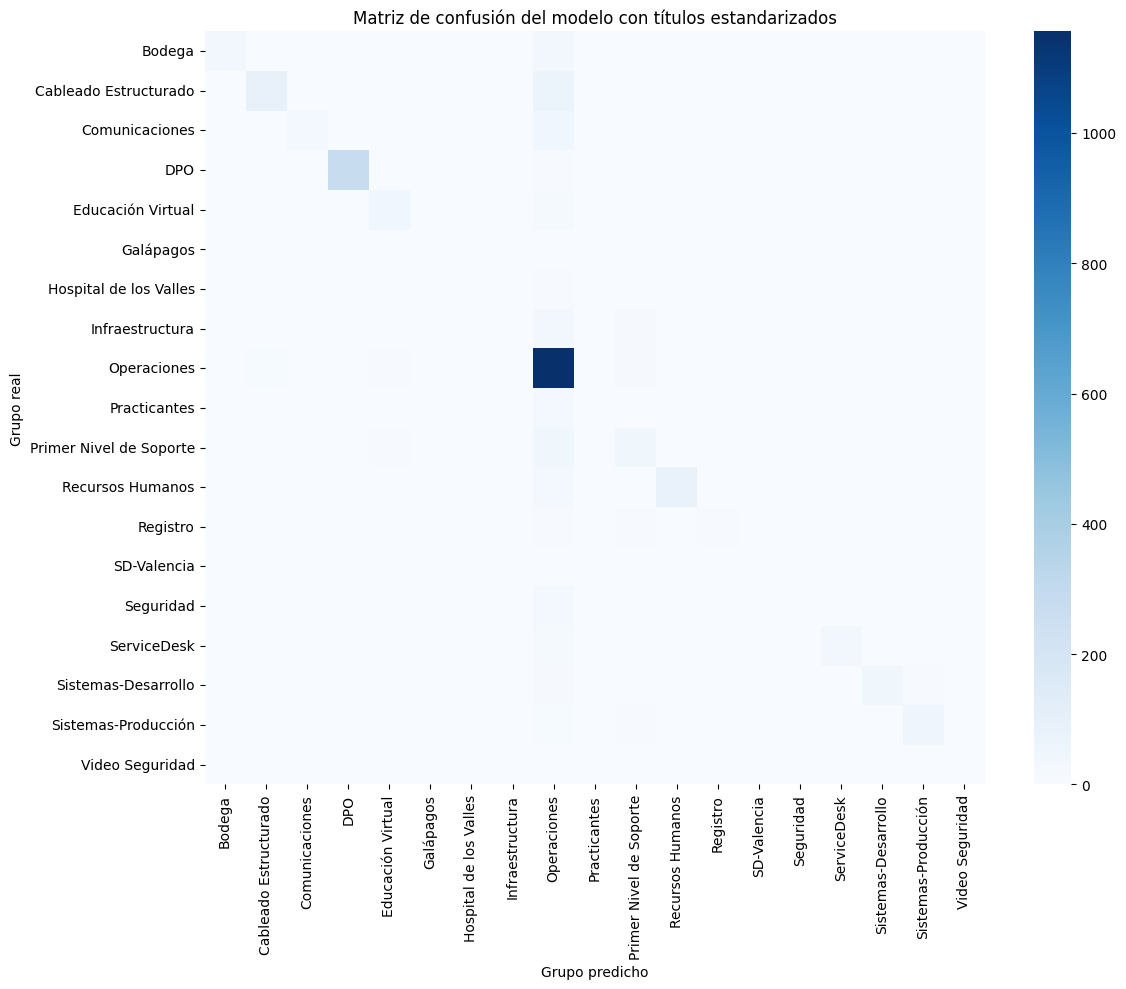

In [67]:
# Matriz de confusión

cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=modelo.classes_,
    yticklabels=modelo.classes_,
    cbar=True
)

plt.title("Matriz de confusión del modelo con títulos estandarizados")
plt.xlabel("Grupo predicho")
plt.ylabel("Grupo real")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 10. Comparación de los experimentos realizados

A continuación, se comparan los resultados obtenidos en los tres experimentos desarrollados hasta esta etapa del proyecto:

1. **Baseline:** modelo de Regresión Logística utilizando TF-IDF sobre el título original y la descripción del ticket.
2. **Baseline balanceado:** variante del modelo baseline incorporando el parámetro `class_weight='balanced'`, con el objetivo de mejorar el desempeño sobre las clases con menor representación.
3. **Títulos estandarizados:** modelo que mantiene la configuración original del baseline, pero sustituye el título original por el resultado del módulo determinista de estandarización antes de construir la representación textual mediante TF-IDF.

Para mantener la comparabilidad entre los experimentos, se conservaron el mismo conjunto de datos, los mismos criterios de filtrado, la misma división estratificada de entrenamiento, validación y prueba, y el mismo enfoque de vectorización y clasificación. De esta manera, las diferencias observadas pueden analizarse en función de la modificación introducida en cada experimento.

In [71]:
comparacion = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "Precision Weighted",
        "Recall Weighted",
        "F1 Weighted"
    ],

    "Baseline": [
        0.7894,
        0.57,
        0.44,
        0.45,
        0.79,
        0.79,
        0.77
    ],

    "Baseline Balanceado": [
        0.6909,
        0.48,
        0.62,
        0.52,
        0.81,
        0.69,
        0.72
    ],

    "Títulos Estandarizados": [
        0.7886,
        0.61,
        0.40,
        0.45,
        0.79,
        0.79,
        0.76
    ]
})

# Diferencias de los experimentos respecto al baseline
comparacion["Dif. Balanceado vs Baseline"] = (
    comparacion["Baseline Balanceado"]
    - comparacion["Baseline"]
)

comparacion["Dif. Estandarizados vs Baseline"] = (
    comparacion["Títulos Estandarizados"]
    - comparacion["Baseline"]
)

comparacion["Dif. Estandarizados vs Balanceado"] = (
    comparacion["Títulos Estandarizados"]
    - comparacion["Baseline Balanceado"]
)

comparacion.round(4)

,Métrica,Baseline,Baseline Balanceado,Títulos Estandarizados,Dif. Balanceado vs Baseline,Dif. Estandarizados vs Baseline,Dif. Estandarizados vs Balanceado
0,Accuracy,0.7894,0.6909,0.7886,-0.0985,-0.0008,0.0977
1,Precision Macro,0.5700,0.4800,0.6100,-0.0900,0.0400,0.1300
2,Recall Macro,0.4400,0.6200,0.4000,0.1800,-0.0400,-0.2200
3,F1 Macro,0.4500,0.5200,0.4500,0.0700,0.0000,-0.0700
4,Precision Weighted,0.7900,0.8100,0.7900,0.0200,0.0000,-0.0200
5,Recall Weighted,0.7900,0.6900,0.7900,-0.1000,0.0000,0.1000
6,F1 Weighted,0.7700,0.7200,0.7600,-0.0500,-0.0100,0.0400


### Análisis de los resultados y del proceso de construcción del módulo

El tercer experimento permitió evaluar el efecto de incorporar un módulo determinista de estandarización de títulos antes del proceso de clasificación. El desarrollo del módulo requirió varias iteraciones de análisis, ajuste y validación, debido a la diversidad de los títulos presentes en el conjunto de datos y a la necesidad de evitar transformaciones que pudieran eliminar información útil para el clasificador.

Inicialmente, se realizó un análisis exploratorio de los títulos más frecuentes con el objetivo de identificar posibles candidatos para estandarización. Este análisis permitió comprobar que la frecuencia de aparición de un título no era suficiente para determinar que debía ser modificado, ya que varios títulos recurrentes, como los relacionados con mantenimiento, monitoreo y laboratorios, contenían información operativa útil.

Posteriormente, se identificó un conjunto reducido de títulos claramente genéricos, entre ellos expresiones como `ayuda`, `solicitud`, `urgente`, `no title`, `D2L`, `Banner`, `WiFi`, `HUBI` y `Workflow`. El análisis de estos casos mostró, sin embargo, que algunos títulos aparentemente genéricos podían estar asociados con diferentes categorías, por lo que no resultaba metodológicamente adecuado aplicar una sustitución indiscriminada.

A partir de este hallazgo, se exploró el uso de información estructurada disponible en los campos del dataset, especialmente la categoría del ticket, para recuperar información del servicio cuando el título original no resultaba suficientemente informativo. También se analizaron patrones presentes en la descripción de los tickets como posible mecanismo complementario. Las pruebas realizadas mostraron que las reglas basadas exclusivamente en palabras clave de la descripción ofrecían una cobertura limitada y podían introducir ambigüedad, por lo que se decidió no convertir este mecanismo en el componente principal de la estandarización.

Durante el análisis también se detectaron títulos generados automáticamente por Service Desk. Aunque inicialmente fueron considerados posibles candidatos para limpieza o estandarización, se observó una gran cantidad de variantes y estructuras encadenadas. Por este motivo, se decidió conservar estos títulos en esta etapa y evitar la incorporación de reglas excesivamente específicas que aumentaran innecesariamente la complejidad del MVP.

Posteriormente, se analizaron los títulos frecuentes junto con su categoría y nivel de consistencia. Esto permitió identificar casos adecuados para mapeos directos y, particularmente, un patrón recurrente relacionado con los laboratorios. Para estos últimos se desarrolló una regla específica que normaliza el nombre del laboratorio conservando su identificador. La primera implementación basada en expresiones regulares presentó un costo computacional excesivo al aplicarse sobre el conjunto completo de datos, por lo que fue sustituida por una estrategia basada en tokens, considerablemente más eficiente.

Una primera aplicación global de la regla de laboratorios alcanzó una cobertura del 14,00 %, pero la revisión manual de una muestra reveló que algunos títulos ya informativos estaban siendo simplificados excesivamente. Por ejemplo, ciertos títulos que describían una solicitud específica relacionada con un laboratorio terminaban reducidos únicamente al identificador del laboratorio. Para evitar esta pérdida de información, la regla fue restringida a los patrones frecuentes previamente identificados y revisados.

La versión final del módulo combinó tres mecanismos controlados: sustitución de títulos completamente genéricos cuando existía información estructurada suficientemente informativa, mapeos directos para títulos frecuentes seleccionados y normalización de patrones recurrentes de laboratorios previamente validados. Como resultado, se modificaron 2.118 de los 16.116 títulos analizados, alcanzando una cobertura del 13,14 %.

Los resultados del modelo muestran que esta estandarización no produjo una mejora global significativa en la clasificación. El Accuracy pasó de 0,7894 en el baseline a 0,7886 con títulos estandarizados, mientras que el F1 Macro se mantuvo en 0,45. El F1 Weighted presentó una variación de 0,77 a 0,76. En términos globales, por tanto, el desempeño puede considerarse prácticamente equivalente al baseline.

Este resultado constituye un hallazgo relevante del experimento: una estandarización determinista y conservadora puede modificar una parte significativa de los títulos sin deteriorar sustancialmente el desempeño global del clasificador, pero las reglas implementadas en esta etapa tampoco generan una mejora observable en las métricas generales. Esto sugiere que el impacto de la calidad del título debe continuar analizándose de manera específica sobre los tickets efectivamente modificados y que una cobertura mayor requeriría mecanismos capaces de interpretar con mayor profundidad el contenido textual del ticket.

## 11. Conclusiones

Los tres experimentos realizados permiten observar diferentes efectos sobre el comportamiento del modelo de clasificación de tickets.

El modelo baseline alcanzó un Accuracy de 0,7894 y estableció el punto de referencia para los experimentos posteriores. La incorporación de `class_weight='balanced'` mejoró el F1 Macro de 0,45 a 0,52 y el Recall Macro de 0,44 a 0,62, mostrando una mayor capacidad para reconocer clases con menor representación. Sin embargo, esta mejora se produjo a costa de una reducción importante del Accuracy, que descendió a 0,6909, y del F1 Weighted.

Por otra parte, el experimento con títulos estandarizados mantuvo un comportamiento global prácticamente equivalente al baseline. El Accuracy obtenido fue de 0,7886 y el F1 Macro permaneció en 0,45. Esto indica que, bajo las reglas implementadas y con una cobertura del 13,14 %, la estandarización determinista de títulos no generó una mejora global significativa en la clasificación, pero tampoco produjo un deterioro relevante del desempeño general.

El proceso iterativo seguido durante la construcción del tercer experimento permitió comprobar que la estandarización de títulos no debe abordarse mediante sustituciones indiscriminadas. La frecuencia de un título, su aparente genericidad o la presencia de determinadas palabras no son suficientes por sí solas para justificar su modificación. La revisión progresiva de los resultados permitió restringir las reglas a casos con mayor nivel de confianza y evitar transformaciones que pudieran eliminar información útil.

En conjunto, los resultados muestran que ninguno de los dos experimentos posteriores supera al baseline en todas las métricas. El modelo balanceado favorece el reconocimiento de clases minoritarias a costa del desempeño global, mientras que el modelo con títulos estandarizados conserva prácticamente el rendimiento original sin demostrar todavía una mejora global en el proceso de clasificación.

## 12. Siguientes pasos

Los resultados obtenidos muestran que el enfoque determinista permite estandarizar de manera controlada determinados patrones de títulos, pero presenta limitaciones para abordar casos que requieren interpretar semánticamente el contenido de la descripción. Durante el desarrollo del módulo se comprobó que ampliar progresivamente el número de reglas puede incrementar la complejidad de la solución y aumentar el riesgo de modificar incorrectamente títulos que ya contienen información relevante.

Como siguiente etapa del proyecto, se propone incorporar un **modelo de lenguaje (LLM)** para la generación o reescritura de títulos en aquellos tickets que requieran una mayor comprensión del contenido textual. El LLM utilizará principalmente la descripción del ticket como contexto para generar un título más claro, descriptivo y representativo de la solicitud realizada por el usuario.

La incorporación del LLM se realizará como un componente separado del experimento determinista desarrollado en este notebook. Esto permitirá evaluar de manera independiente su capacidad para mejorar los títulos y analizar posteriormente su impacto sobre la clasificación del grupo resolutorio.

El flujo experimental previsto para esta siguiente etapa será:

**Título original + Descripción → Evaluación de la necesidad de reescritura → Reescritura mediante LLM cuando corresponda → Título resultante + Descripción → TF-IDF → Clasificador de grupo resolutorio**

Para mantener la comparabilidad con los experimentos anteriores, se conservarán, en la medida de lo posible, el mismo conjunto de datos, la misma división de entrenamiento, validación y prueba, y el mismo modelo de clasificación. De esta manera, será posible determinar si una reescritura con mayor capacidad de interpretación semántica produce un impacto diferente al observado con la estandarización basada exclusivamente en reglas.

Adicionalmente, como parte de la evaluación posterior del prototipo, podrá analizarse específicamente el subconjunto de tickets cuyos títulos fueron modificados. Esto permitirá identificar si las estrategias de mejora del título generan beneficios localizados en la clasificación que podrían no ser visibles al observar únicamente las métricas globales del conjunto completo.